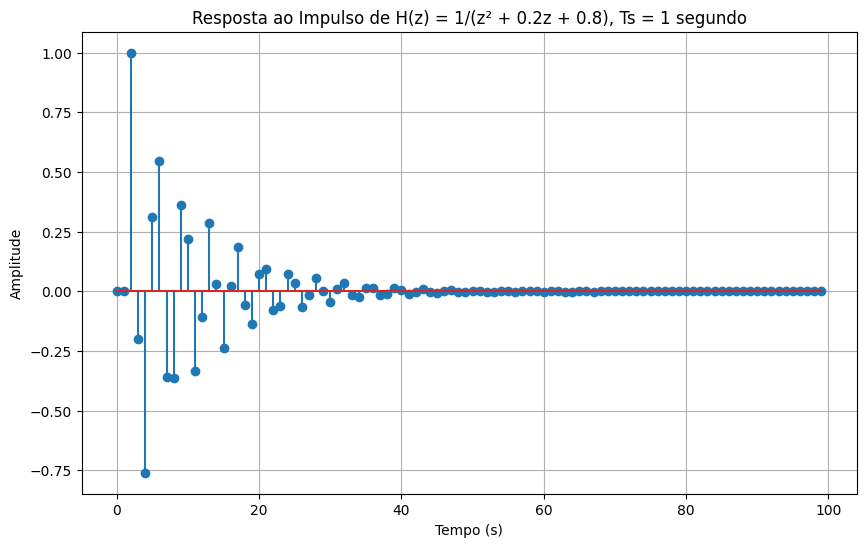

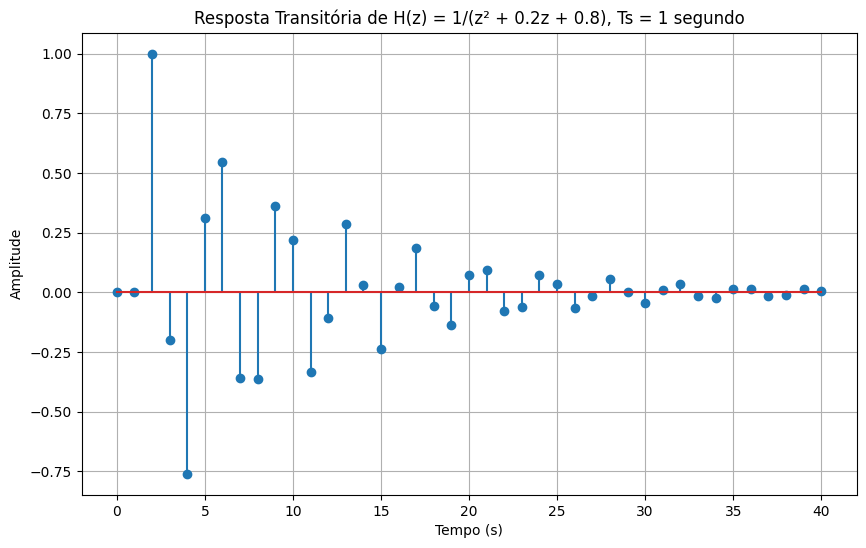

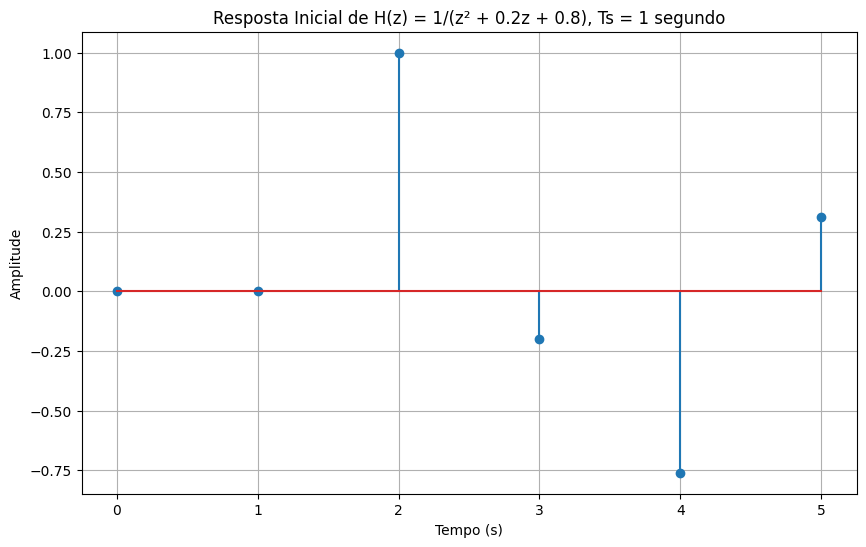

In [1]:
import numpy as np
from scipy import signal

import matplotlib.pyplot as plt

# Define the system in terms of denominator coefficients
# For H(z) = 1/(z² + 0.2z + 0.8), the denominator is [1, 0.2, 0.8]
num = [1]  # Numerator coefficients
den = [1, 0.2, 0.8]  # Denominator coefficients

# Set the number of samples and the sampling period
n_samples = 100
Ts = 1  # Sampling period in seconds

# Compute the impulse response
k, impulse_response = signal.dimpulse((num, den, Ts), n=100)
k, impulse_response = np.squeeze(k), np.squeeze(np.array(impulse_response))

# Plot the impulse response
plt.figure(figsize=(10, 6))
plt.stem(k * Ts, impulse_response)
plt.title("Resposta ao Impulso de H(z) = 1/(z² + 0.2z + 0.8), Ts = 1 segundo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Plot the transient response
transient_t = k * Ts <= 40  # Focus on the first 40 seconds
plt.figure(figsize=(10, 6))
plt.stem(k[transient_t], impulse_response[transient_t])
plt.title("Resposta Transitória de H(z) = 1/(z² + 0.2z + 0.8), Ts = 1 segundo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Plot the start of the response, to focus on the dead time
initial_t = k * Ts <= 5  # Focus on the first 5 seconds
plt.figure(figsize=(10, 6))
plt.stem(k[initial_t], impulse_response[initial_t])
plt.title("Resposta Inicial de H(z) = 1/(z² + 0.2z + 0.8), Ts = 1 segundo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

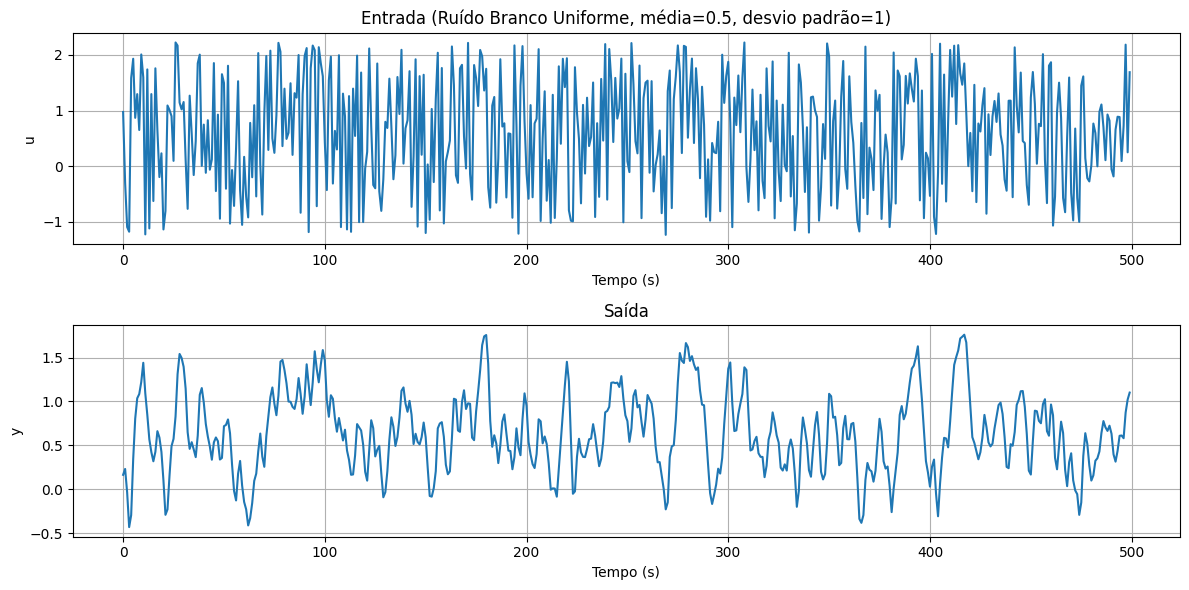

In [2]:
# H(z) = ( 0.1701z + 0.1208 ) / ( z² - z + 0.2725 )
num = [0.1701, 0.1208]  # Numerator coefficients
den = [1, -1, 0.2725]  # Denominator coefficients

# Set the number of samples and the sampling period
n_samples = 500
Ts = 1  # Sampling period in seconds

# Set the white random input generator
rng = np.random.default_rng(seed=0)
half_range = np.sqrt(
    3
)  # for uniform, std = (b-a)/sqrt(12) -> half_range = sqrt(12)/2 = sqrt(3)
a = 0.5 - half_range
b = 0.5 + half_range

# generate uniform white noise with mean 0.5 and std 1
u = rng.uniform(a, b, size=n_samples)

# simulate system response to u
y_tf = signal.lfilter(num, den, u)

# time axis
t = np.arange(n_samples) * Ts

# plots
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, u)
plt.title("Entrada (Ruído Branco Uniforme, média=0.5, desvio padrão=1)")
plt.xlabel("Tempo (s)")
plt.ylabel("u")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, y_tf)
plt.title("Saída")
plt.xlabel("Tempo (s)")
plt.ylabel("y")
plt.grid(True)

plt.tight_layout()
plt.show()

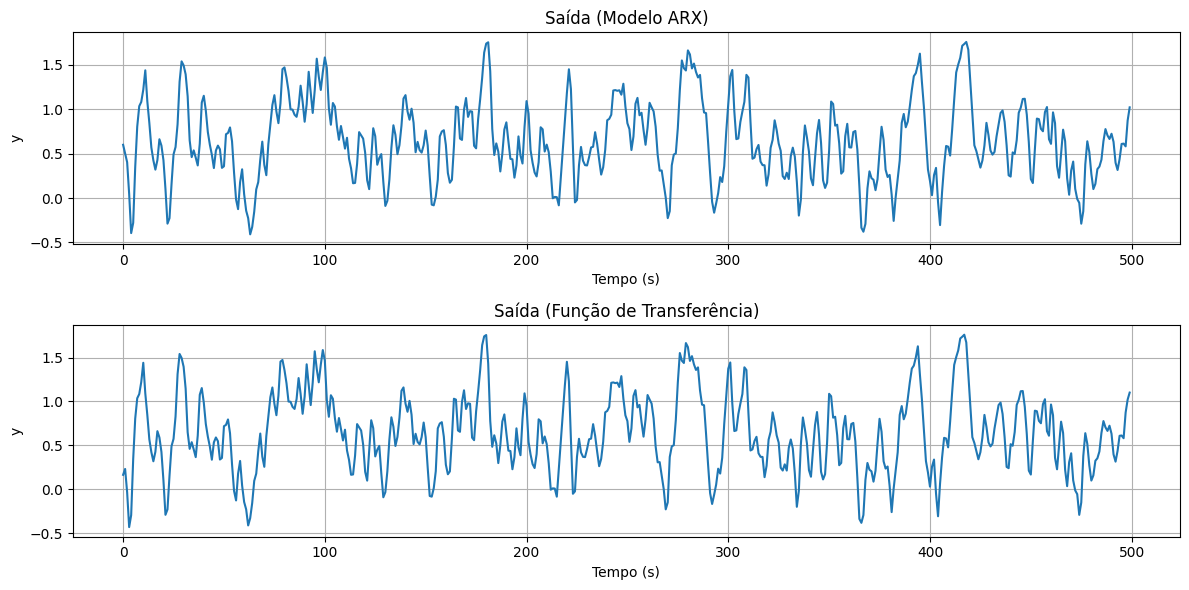

In [3]:
# Set the state-space model y(k) = y(k-1) - 0.2725*y(k-2) + 0.1701*u(k-1) + 0.1208*u(k-2) + e(k)
def arx(k, y, u, e):
    return y[k - 1] - 0.2725 * y[k - 2] + 0.1701 * u[k - 1] + 0.1208 * u[k - 2] + e[k]

# Set the initial conditions
y_arx = np.zeros(n_samples)
y_arx[0], y_arx[1] = 0.6, 0.5

# No noise, to compare with the transfer function
e = np.zeros(n_samples)

# Simulate ARX model
for k in range(2, n_samples):
    y_arx[k] = arx(k, y_arx, u, e)

# Plot the output of the ARX model and the TF side by side, in the same figure
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, y_arx)
plt.title("Saída (Modelo ARX)")
plt.xlabel("Tempo (s)")
plt.ylabel("y")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, y_tf)
plt.title("Saída (Função de Transferência)")
plt.xlabel("Tempo (s)")
plt.ylabel("y")
plt.grid(True)

plt.tight_layout()
plt.show()

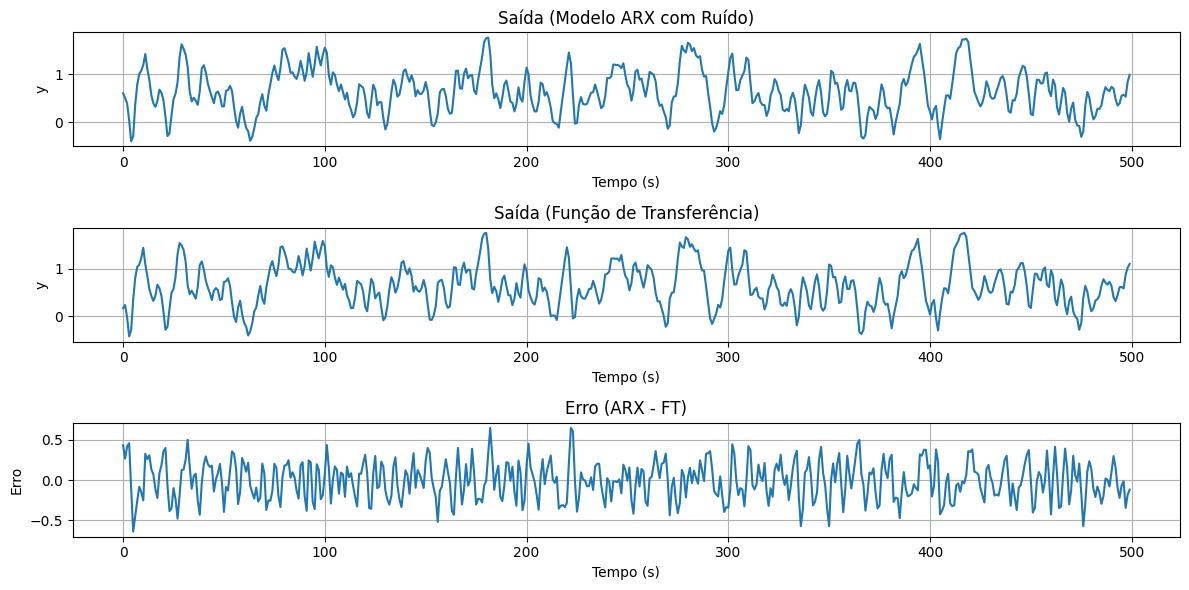

Média da diferença (ARX - FT): -0.0054
Desvio padrão da diferença: 0.2344
Máximo do absoluto da diferença: 0.6513


In [4]:
# Compute the standard deviation of the output
std_y = np.std(y_arx)

# Set the noise as a gaussian with mean 0 and standard deviation 0.05*std_y
e = rng.normal(0, 0.05 * std_y, n_samples)

# Simulate the ARX model with noise

# Initialize the ARX output
y_arx = np.zeros(n_samples)
y_arx[0], y_arx[1] = 0.6, 0.5

# Run the ARX model
for k in range(2, n_samples):
    y_arx[k] = arx(k, y_arx, u, e)

# Compute the error
diff = y_arx - y_tf

# Plot the output of the ARX model, the TF and the error side by side, in the same figure
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(t, y_arx)
plt.title("Saída (Modelo ARX com Ruído)")
plt.xlabel("Tempo (s)")
plt.ylabel("y")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, y_tf)
plt.title("Saída (Função de Transferência)")
plt.xlabel("Tempo (s)")
plt.ylabel("y")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, diff)
plt.title("Erro (ARX - FT)")
plt.xlabel("Tempo (s)")
plt.ylabel("Erro")
plt.grid(True)

plt.tight_layout()
plt.show()

# Compute metrics of the difference between the ARX model and the TF model
mean_diff = np.mean(diff)
std_diff = np.std(diff)
max_diff = np.max(np.abs(diff))

print(f"Média da diferença (ARX - FT): {mean_diff:.4f}")
print(f"Desvio padrão da diferença: {std_diff:.4f}")
print(f"Máximo do absoluto da diferença: {max_diff:.4f}")

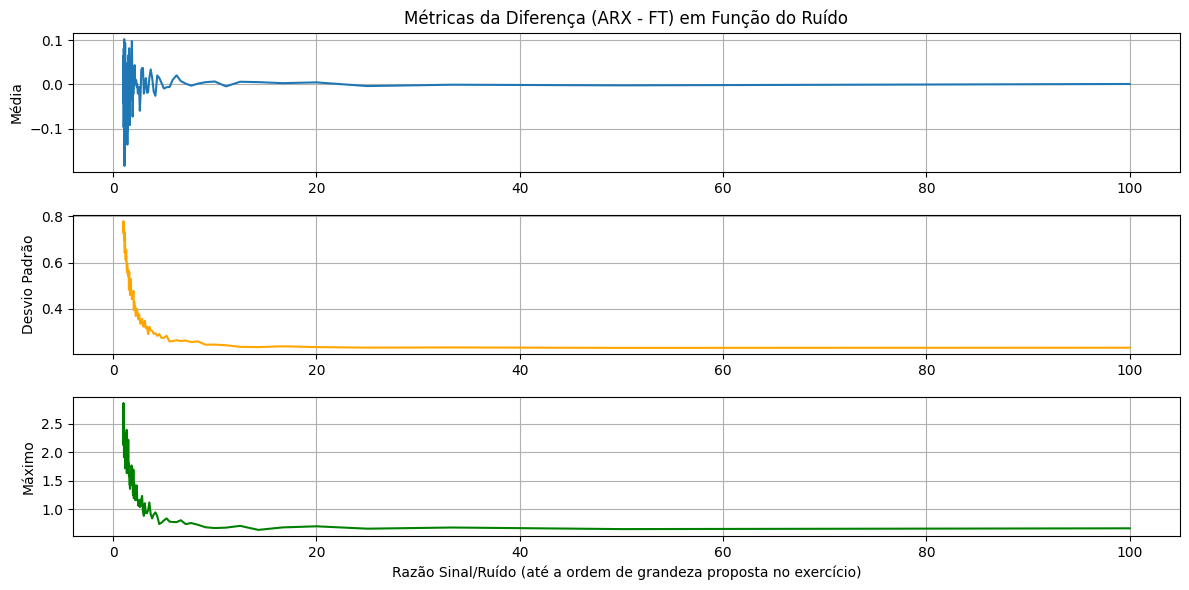

In [5]:
# Sweep over different noise levels
noise_sweep = np.linspace(0.01 * std_y, std_y, 100)

mean_diffs = []
std_diffs = []
max_diffs = []

# Run the sweep
for noise in noise_sweep:

    # Generate noise
    e = rng.normal(0, noise, n_samples)

    # Simulate the ARX model with noise
    y_arx = np.zeros(n_samples)
    y_arx[0], y_arx[1] = 0.6, 0.5

    # Run the ARX model
    for k in range(2, n_samples):
        y_arx[k] = arx(k, y_arx, u, e)

    # Compute metrics of the difference between the ARX model and the TF model
    diff = y_arx - y_tf
    mean_diffs.append(np.mean(diff))
    std_diffs.append(np.std(diff))
    max_diffs.append(np.max(np.abs(diff)))

# Compute the input noise ratio sweep
input_noise_ratio_sweep = std_y / noise_sweep

# Plot the metrics for the noise sweep, in the same figure
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(input_noise_ratio_sweep, mean_diffs, label="Média")
plt.title("Métricas da Diferença (ARX - FT) em Função do Ruído")
plt.ylabel("Média")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(input_noise_ratio_sweep, std_diffs, label="Desvio Padrão", color="orange")
plt.ylabel("Desvio Padrão")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(input_noise_ratio_sweep, max_diffs, label="Máximo", color="green")
plt.ylabel("Máximo")
plt.xlabel("Razão Sinal/Ruído (até a ordem de grandeza proposta no exercício)")
plt.grid(True)

plt.tight_layout()
plt.show()
